### ------------- **Data Analysis Python Project - Blinkit Analysis** -------------------

##### **Import Libraries**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### **Sample Data**

In [6]:
df = pd.read_csv('blinkit_data.csv')
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [38]:
df.tail()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8518,Low Fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,Low Fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,Low Fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,Regular,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,Regular,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


#### **Size of the data**

In [ ]:
df.shape  

(8523, 12)

#### **All Columns**

In [11]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

#### **Data Types of Columns**

In [13]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

#### **Data Cleaning**

In [14]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat', 'low fat', 'LF', 'reg'], dtype=object)

In [15]:
df['Item Fat Content'] = df['Item Fat Content'].replace({'LF':'Low Fat',
                                                        'low fat':'Low Fat',
                                                        'reg':'Regular'})

In [16]:
df['Item Fat Content'].unique()

array(['Regular', 'Low Fat'], dtype=object)

#### **Business Requirements**

### **KPI's Requirements**
- **Toatl Sales** - The overall revenue generated from all items sold
- **Average sales** - The avg revenue per sale
- **No. of Items** - The total count of different items sold
- **Average Ratings** - The average customer ratings for items sold

In [25]:
# TOTAL SALES
total_sales = df['Sales'].sum()

# AVERAGE SALES
avg_sales = df['Sales'].mean()

# No of Items Sold
no_of_items_sold = df['Sales'].count()

# Average Ratings
avg_ratings = df['Rating'].mean()

# Display
print(f'Total Sales: ${total_sales:,.1f}')
print(f'Average Sales: ${avg_sales:,.1f}')
print(f'No of Items Sales: ${no_of_items_sold:,.0f}')
print(f'Average Ratings: ${avg_ratings:,.1f}')

Total Sales: $1,201,681.5
Average Sales: $141.0
No of Items Sales: $8,523
Average Ratings: $4.0


### **Chart's Requirements**
1. **Total Sales by Fat Content:**<br>
	- **Objective**: Analyze the impact of fat content on total sales.<br>
	- **Additional KPI Metrics**: Assess how other KPIs (Average Sales, Number of Items, Average Rating) vary with fat content. <br>
	- **Chart Type**: Donut Chart.<br>

2. **Total Sales by Item Type:** <br>
	- **Objective**: Identify the performance of different item types in terms of total sales.<br>
	- **Additional KPI Metrics**: Assess how other KPIs (Average Sales, Number of Items, Average Rating) vary with fat content.<br>
	- **Chart Type**: Bar Chart.<br>

3. **Fat Content by Outlet for Total Sales:**<br>
	- **Objective**: Compare total sales across different outlets segmented by fat content.<br>
	- **Additional KPI Metrics**: Assess how other KPIs (Average Sales, Number of Items, Average Rating) vary with fat content.<br>
	- **Chart Type**: Stacked Column Chart.<br>

4. **Total Sales by Outlet Establishment:**<br>
	- **Objective**: Evaluate how the age or type of outlet establishment influences total sales.<br>
	- **Chart Type**: Line Chart.<br>

5. **Sales by Outlet Size:**<br>
	- **Objective**: Analyze the correlation between outlet size and total sales.<br>
	- **Chart Type**: Donut/ Pie Chart.<br>

6. **Sales by Outlet Location:**<br>
	- **Objective**: Assess the geographic distribution of sales across different locations.<br>
	- **Chart Type**: Funnel Map.<br>



#### **Total Sales by Fat Content:**

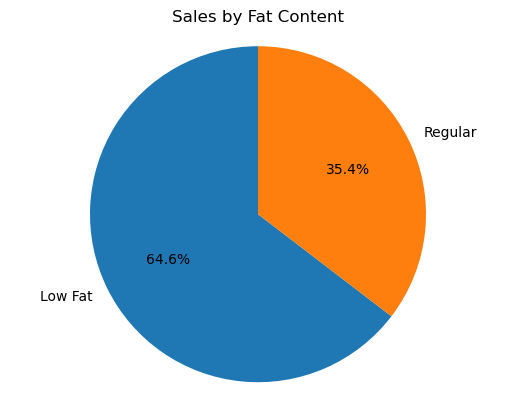

In [30]:
sales_by_fat = df.groupby('Item Fat Content')['Sales'].sum()

plt.pie(sales_by_fat, labels= sales_by_fat.index,
                        autopct="%.1f%%",
                        startangle=90)

plt.title("Sales by Fat Content")
plt.axis('equal')
plt.show()

#### **Total Sales by Item Type:** 

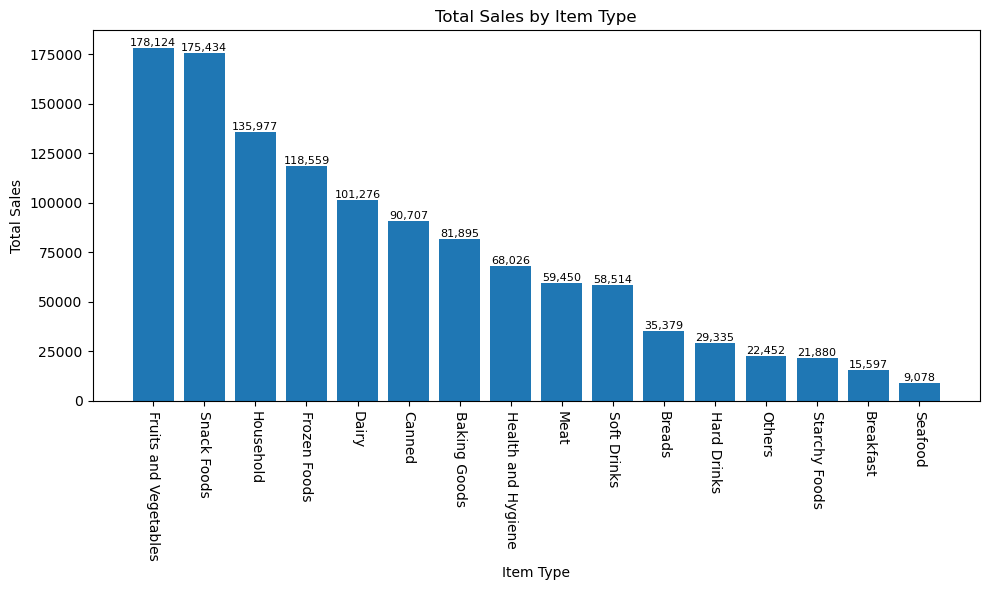

In [ ]:
sales_by_type = df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(sales_by_type.index, sales_by_type.values)

plt.xticks(rotation=-90)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Total Sales by Item Type")

# labels
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### **Fat Content by Outlet for Total Sales:**

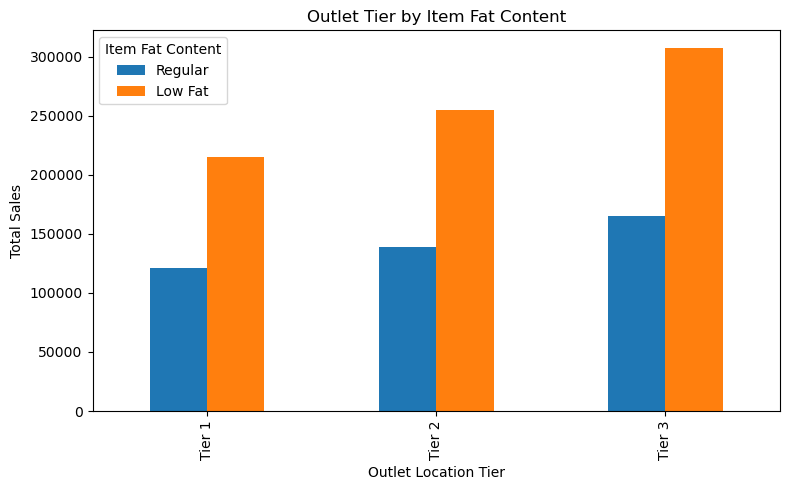

In [34]:
grouped = df.groupby(["Outlet Location Type", "Item Fat Content"])["Sales"].sum().unstack()
grouped =  grouped[["Regular", "Low Fat"]]

ax = grouped.plot(kind='bar', figsize=(8,5), title="Outlet Tier by Item Fat Content")
plt.xlabel("Outlet Location Tier")
plt.ylabel("Total Sales")
plt.legend(title="Item Fat Content")
plt.tight_layout()
plt.show()

#### **Total Sales by Outlet Establishment:**

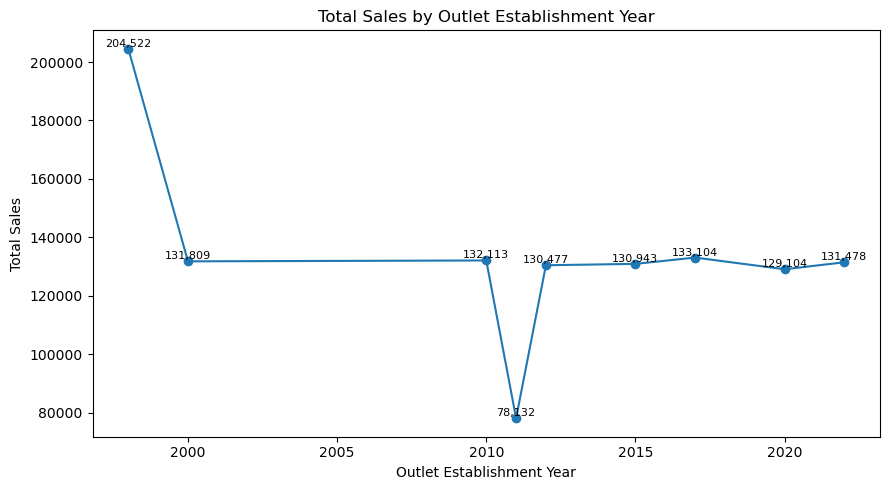

In [35]:
sales_by_year = df.groupby("Outlet Establishment Year")['Sales'].sum().sort_index()

plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index, sales_by_year.values, marker='o', linestyle="-")

plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.title("Total Sales by Outlet Establishment Year")

for x,y in zip(sales_by_year.index, sales_by_year.values):
    plt.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### **Sales by Outlet Size**

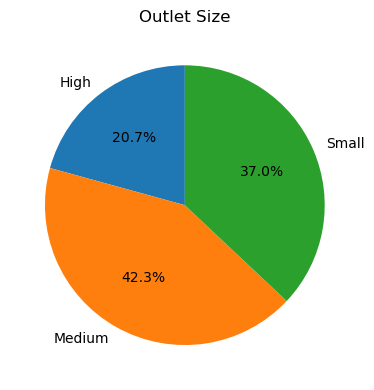

In [36]:
sales_by_size = df.groupby("Outlet Size")["Sales"].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_size, labels=sales_by_size.index, autopct="%1.1f%%", startangle=90)
plt.title("Outlet Size")
plt.tight_layout()
plt.show()

#### **Sales by Outlet Location**

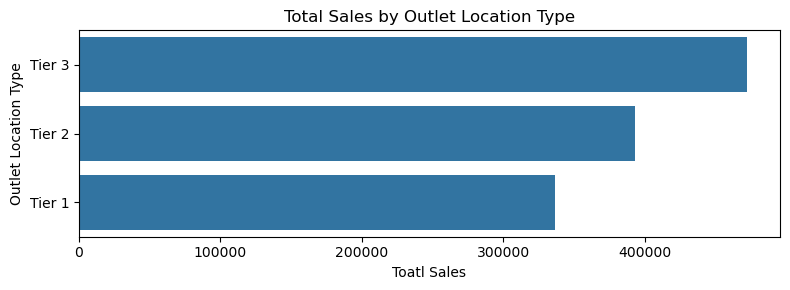

In [ ]:
sales_by_location = df.groupby("Outlet Location Type")["Sales"].sum().reset_index()
sales_by_location = sales_by_location.sort_values("Sales", ascending=False)

plt.figure(figsize=(8,3)) # smaller height, enough width
ax = sns.barplot(x="Sales", y="Outlet Location Type", data=sales_by_location)


plt.xlabel("Toatl Sales")
plt.ylabel("Outlet Location Type")
plt.title("Total Sales by Outlet Location Type")

plt.tight_layout()
plt.show()